# Lab Assignment - 3

# Objective: Build and compare Scikit-learn preprocessing pipelines and evaluate two classification models.

In [272]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Part A - Data Loading and Preprocessing with Scikit-learn

# Task 1 - Load and Understand the Dataset

## Load hotel_bookings.csv. Use head(), shape, info(), describe(), and dtypes.

In [251]:
hotel_df = pd.read_csv("hotel_bookings.csv")

In [252]:
hotel_df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [253]:
hotel_df.shape

(119390, 32)

In [254]:
hotel_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [255]:
hotel_df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [256]:
hotel_df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

## Check the class distribution of is_canceled and use it as the target y.

In [257]:
hotel_df["is_canceled"].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [258]:
hotel_df["is_canceled"].value_counts(normalize=True) * 100

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

In [259]:
y = hotel_df["is_canceled"]

## Create X from the remaining usable features. Identify numerical and categorical columns.

In [261]:
X = hotel_df.drop(columns=["is_canceled"])

In [262]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumber of Numerical Features:", len(numerical_cols))
print("Number of Categorical Features:", len(categorical_cols))


Numerical Columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']

Number of Numerical Features: 19
Number of Categorical Features: 12


# Task 2 - Missing Values, Leakage, and Outliers

## Find the missing-value count and percentage for every column.

In [193]:
missing_count = hotel_df.isnull().sum()
print(missing_count)

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [265]:
missing_percentage = ((missing_count / len(hotel_df)) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Percentage", ascending=False)

print(missing_summary)

          Missing Count  Missing Percentage
company          112593               94.31
agent             16340               13.69
country             488                0.41
children              4                0.00


## Identify columns with very high missingness. Drop them only if justified and state the reason.

In [266]:
hotel_df = hotel_df.drop(columns=["company"])

#### Company was dropped because it contains a very high proportion of missing values that is 90%.

## Remove columns that directly reveal the final booking outcome, such as reservation_status and reservation_status_date.


In [267]:
leakage_columns = [
    "reservation_status",
    "reservation_status_date"
]

hotel_df = hotel_df.drop(columns=leakage_columns)

In [269]:
hotel_df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='str')

## Check selected numerical features for outliers using boxplots and/or the IQR method.

In [271]:
selected_numeric = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "adr",
    "booking_changes",
    "days_in_waiting_list",
    "total_of_special_requests"
]

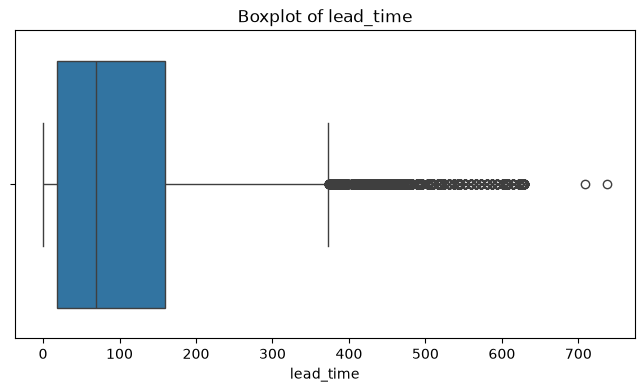

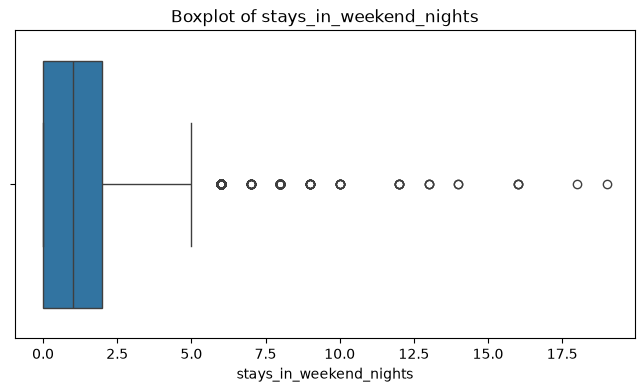

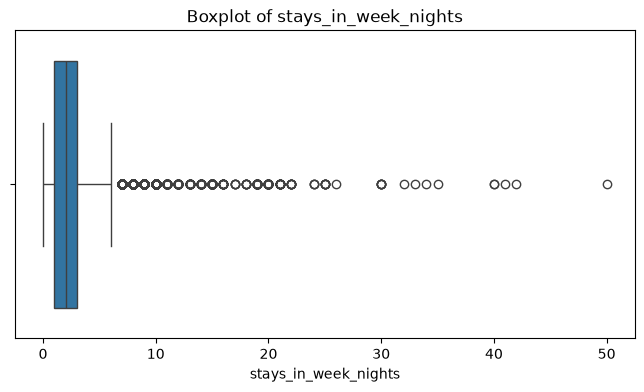

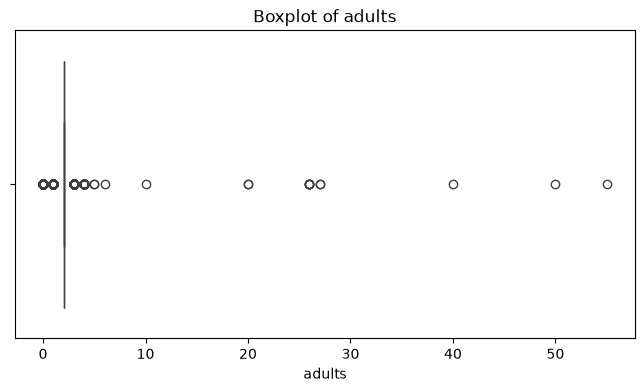

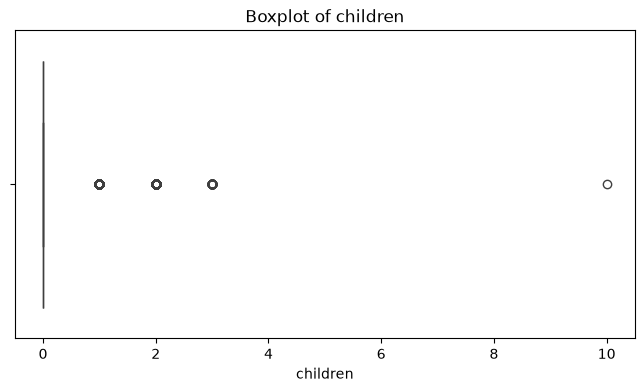

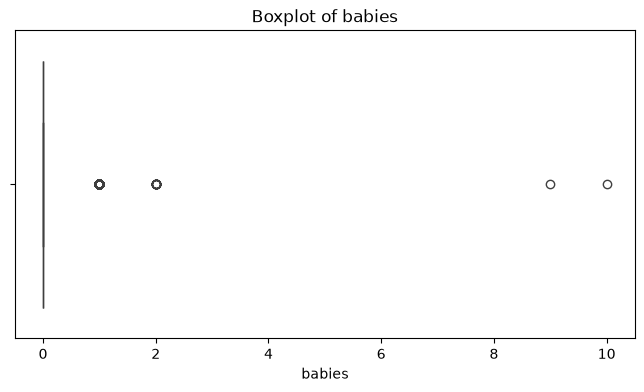

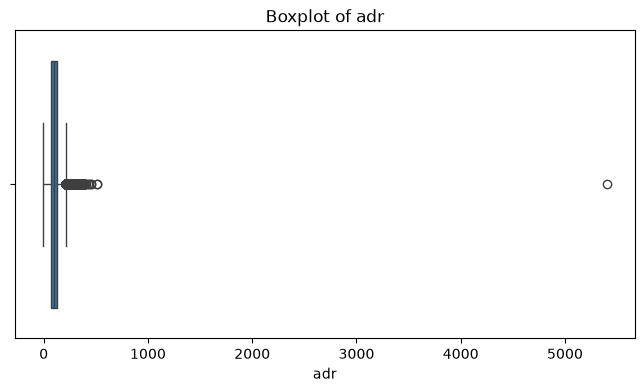

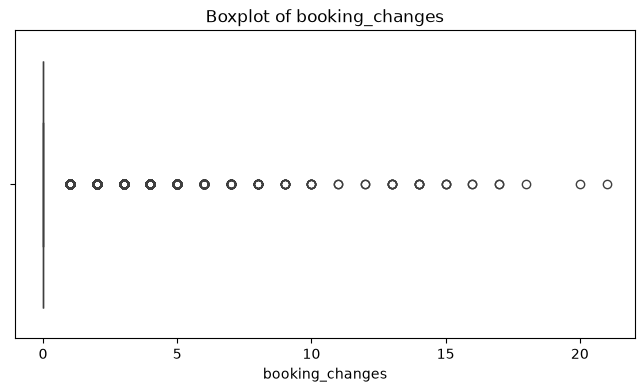

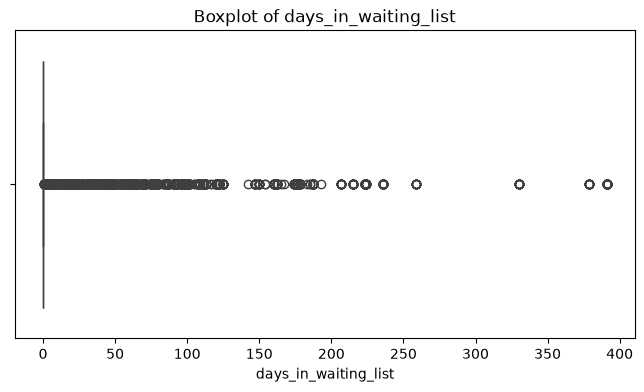

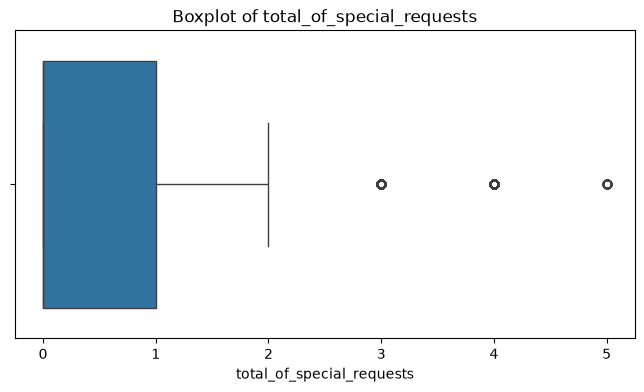

In [273]:
for col in selected_numeric:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [274]:
outlier_summary = []
for column in outlier_columns:
    Q1 = hotel_df[column].quantile(0.25)
    Q3 = hotel_df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = hotel_df[
        (hotel_df[column] < lower_bound) |
        (hotel_df[column] > upper_bound)
    ]
    outlier_summary.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    })
outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,lead_time,18.00,160.0,142.00,-195.000,373.000,3005
1,adr,69.29,126.0,56.71,-15.775,211.065,3793
2,stays_in_weekend_nights,0.00,2.0,2.00,-3.000,5.000,265
3,stays_in_week_nights,1.00,3.0,2.00,-2.000,6.000,3354
4,adults,2.00,2.0,0.00,2.000,2.000,29710
5,children,0.00,0.0,0.00,0.000,0.000,8590
6,babies,0.00,0.0,0.00,0.000,0.000,917
7,previous_cancellations,0.00,0.0,0.00,0.000,0.000,6484
8,booking_changes,0.00,0.0,0.00,0.000,0.000,18076
9,days_in_waiting_list,0.00,0.0,0.00,0.000,0.000,3698


## Remove only clear/extreme outliers and report how many rows were removed.

In [276]:
print(hotel_df["adr"].describe())

print("\nHighest ADR values:")
print(
    hotel_df[["adr", "hotel", "adults", "children", "babies"]]
    .sort_values("adr", ascending=False)
    .head(20)
)

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

Highest ADR values:
            adr         hotel  adults  children  babies
48515   5400.00    City Hotel       2       0.0       0
111403   510.00    City Hotel       1       0.0       0
15083    508.00  Resort Hotel       2       0.0       0
103912   451.50    City Hotel       2       2.0       0
13142    450.00  Resort Hotel       2       0.0       0
13391    437.00  Resort Hotel       2       2.0       0
39155    426.25  Resort Hotel       2       2.0       0
39568    402.00  Resort Hotel       3       1.0       0
39118    397.38  Resort Hotel       3       2.0       0
13323    392.00  Resort Hotel       2       1.0       0
39517    392.00  Resort Hotel       2       0.0       0
39543    388.00  Resort Hotel       3       1.0       0
13406    388.00  Resort Hotel       3    

In [277]:
before = len(hotel_df)

# Remove clearly invalid/extreme ADR values
hotel_df = hotel_df[(hotel_df["adr"] >= 0) & (hotel_df["adr"] < 1000)].copy()

after = len(hotel_df)

rows_removed = before - after

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", rows_removed)

Rows before: 119390
Rows after: 119388
Rows removed: 2


In [278]:
print(hotel_df["adr"].describe())

print("\nMinimum ADR:", hotel_df["adr"].min())
print("Maximum ADR:", hotel_df["adr"].max())

count    119388.000000
mean        101.787650
std          48.152738
min           0.000000
25%          69.290000
50%          94.575000
75%         126.000000
max         510.000000
Name: adr, dtype: float64

Minimum ADR: 0.0
Maximum ADR: 510.0


# Task 3 - Create Two Preprocessing Pipelines

## Split the data using train_test_split(test_size=0.2, stratify=y, random_state=42). Use the same split for all experiments.

In [280]:
y = hotel_df["is_canceled"]
X = hotel_df.drop(columns=["is_canceled"])

In [281]:
numerical_cols = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [282]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [283]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (95510, 28)
X_test shape: (23878, 28)
y_train shape: (95510,)
y_test shape: (23878,)


In [284]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
is_canceled
0    0.629589
1    0.370411
Name: proportion, dtype: float64

Testing target distribution:
is_canceled
0    0.629575
1    0.370425
Name: proportion, dtype: float64


## For numerical columns, use KNNImputer(n_neighbors=5) for missing values.

In [285]:
from sklearn.impute import KNNImputer

In [286]:
knn_imputer = KNNImputer(n_neighbors=5)

## For categorical columns, use SimpleImputer(strategy="most_frequent") and OneHotEncoder(handle_unknown="ignore").

In [304]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

## Pipeline A: KNNImputer + StandardScaler for numerical features.

In [305]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

numeric_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

## Pipeline B: KNNImputer + MinMaxScaler for numerical features.

In [306]:
from sklearn.preprocessing import MinMaxScaler

numeric_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

## Use ColumnTransformer and Pipeline so that preprocessing is fitted only on the training data.

In [307]:
from sklearn.compose import ColumnTransformer

preprocessor_A = ColumnTransformer([
    ("num", numeric_pipeline_A, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [308]:
preprocessor_B = ColumnTransformer([
    ("num", numeric_pipeline_B, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [309]:
pipeline_A = Pipeline([
    ("preprocessor", preprocessor_A)
])
pipeline_B = Pipeline([
    ("preprocessor", preprocessor_B)
])

# Part B - Model Training and Performance Evaluation

# Task 4 - Train Two Classification Models

## Train LogisticRegression(max_iter=1000) using Pipeline A and Pipeline B.

In [311]:
X_train_A = pipeline_A.fit_transform(X_train)

X_test_A = pipeline_A.transform(X_test)


X_train_B = pipeline_B.fit_transform(X_train)

X_test_B = pipeline_B.transform(X_test)

In [313]:
print("\nPipeline A - StandardScaler")
print("Training shape:", X_train_A.shape)
print("Testing shape :", X_test_A.shape)

print("\nPipeline B - MinMaxScaler")
print("Training shape:", X_train_B.shape)
print("Testing shape :", X_test_B.shape)


Pipeline A - StandardScaler
Training shape: (95510, 251)
Testing shape : (23878, 251)

Pipeline B - MinMaxScaler
Training shape: (95510, 251)
Testing shape : (23878, 251)


In [314]:
print("NaN in Pipeline A:", np.isnan(X_train_A.data).any())
print("NaN in Pipeline B:", np.isnan(X_train_B.data).any())

NaN in Pipeline A: False
NaN in Pipeline B: False


In [315]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_A.fit(X_train, y_train)
logistic_B.fit(X_train, y_train)
print("All two model-pipeline combinations trained successfully.")

All two model-pipeline combinations trained successfully.


## Train DecisionTreeClassifier(random_state=42) using Pipeline A and Pipeline B.

In [316]:
from sklearn.tree import DecisionTreeClassifier

In [317]:
tree_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_A.fit(X_train, y_train)
tree_B.fit(X_train, y_train)

print("All decsion tree model-pipeline combinations trained successfully.")

All decsion tree model-pipeline combinations trained successfully.


# Task 5 - Evaluate and Compare the Four Results

## For each experiment, calculate training accuracy, testing accuracy, precision, recall, and F1-score.

In [318]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [319]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)
    
    precision = precision_score(y_test, test_pred)
    recall = recall_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred)
    
    return {
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Train-Test Gap": train_accuracy - test_accuracy
    }

In [320]:
results = []

# Logistic Regression + StandardScaler
result = evaluate_model(
    logistic_A,
    X_train,
    y_train,
    X_test,
    y_test
)
result["Model"] = "Logistic Regression"
result["Pipeline"] = "Pipeline A - StandardScaler"
results.append(result)


# Logistic Regression + MinMaxScaler
result = evaluate_model(
    logistic_B,
    X_train,
    y_train,
    X_test,
    y_test
)
result["Model"] = "Logistic Regression"
result["Pipeline"] = "Pipeline B - MinMaxScaler"
results.append(result)


# Decision Tree + StandardScaler
result = evaluate_model(
    tree_A,
    X_train,
    y_train,
    X_test,
    y_test
)
result["Model"] = "Decision Tree"
result["Pipeline"] = "Pipeline A - StandardScaler"
results.append(result)


# Decision Tree + MinMaxScaler
result = evaluate_model(
    tree_B,
    X_train,
    y_train,
    X_test,
    y_test
)
result["Model"] = "Decision Tree"
result["Pipeline"] = "Pipeline B - MinMaxScaler"
results.append(result)

## Create a final comparison table containing all four model-pipeline combinations.

In [326]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df[
    [
        "Model",
        "Pipeline",
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Train-Test Gap"
    ]
]

comparison = comparison_df.round(4)
comparison_df1 = (comparison_df*100).round(2)
comparison_df1

,Model,Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Gap
0,Logistic RegressionLogistic RegressionLogistic...,Pipeline A - StandardScalerPipeline A - Standa...,81.94,81.53,80.36,66.37,72.69,0.41
1,Logistic RegressionLogistic RegressionLogistic...,Pipeline B - MinMaxScalerPipeline B - MinMaxSc...,81.55,81.22,80.24,65.40,72.06,0.34
2,Decision TreeDecision TreeDecision TreeDecisio...,Pipeline A - StandardScalerPipeline A - Standa...,99.63,86.16,80.94,81.93,81.44,13.46
3,Decision TreeDecision TreeDecision TreeDecisio...,Pipeline B - MinMaxScalerPipeline B - MinMaxSc...,99.63,86.15,80.94,81.90,81.42,13.48


## Plot a confusion matrix for the best Logistic Regression result and the best Decision Tree result.

In [327]:
logistic_results = comparison_df[
    comparison_df["Model"] == "Logistic Regression"
]

best_logistic = logistic_results.loc[
    logistic_results["F1-Score"].idxmax()
]

print("Best Logistic Regression:")
print(best_logistic)

Best Logistic Regression:
Model                        Logistic Regression
Pipeline             Pipeline A - StandardScaler
Training Accuracy                       0.819443
Testing Accuracy                        0.815311
Precision                               0.803559
Recall                                  0.663652
F1-Score                                0.726935
Train-Test Gap                          0.004132
Name: 0, dtype: object


In [328]:
tree_results = comparison_df[
    comparison_df["Model"] == "Decision Tree"
]

best_tree = tree_results.loc[
    tree_results["F1-Score"].idxmax()
]

print("Best Decision Tree:")
print(best_tree)

Best Decision Tree:
Model                              Decision Tree
Pipeline             Pipeline A - StandardScaler
Training Accuracy                       0.996262
Testing Accuracy                         0.86163
Precision                               0.809449
Recall                                  0.819333
F1-Score                                0.814361
Train-Test Gap                          0.134632
Name: 2, dtype: object


In [329]:
if best_logistic["Pipeline"] == "Pipeline A - StandardScaler":
    best_logistic_model = logistic_A
else:
    best_logistic_model = logistic_B

if best_tree["Pipeline"] == "Pipeline A - StandardScaler":
    best_tree_model = tree_A
else:
    best_tree_model = tree_B

print("Best Logistic Regression:", best_logistic["Pipeline"])
print("Best Decision Tree:", best_tree["Pipeline"])

Best Logistic Regression: Pipeline A - StandardScaler
Best Decision Tree: Pipeline A - StandardScaler


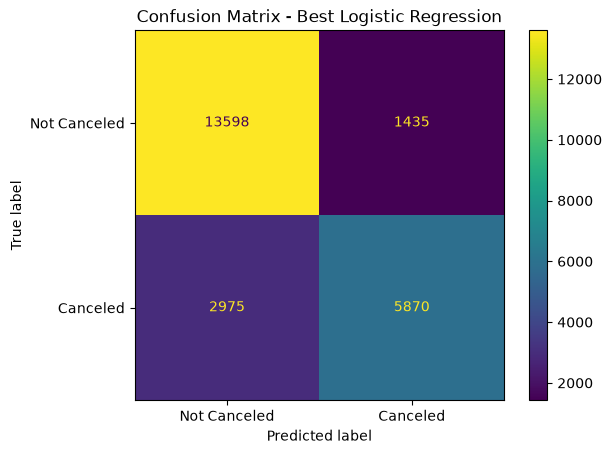

In [330]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_logistic = best_logistic_model.predict(X_test)
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled", "Canceled"]
)
disp.plot()
plt.title("Confusion Matrix - Best Logistic Regression")
plt.show()

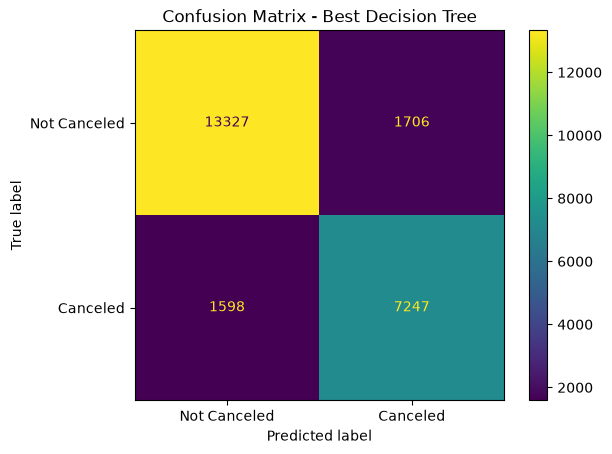

In [331]:
y_pred_tree = best_tree_model.predict(X_test)
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled", "Canceled"]
)
disp.plot()
plt.title("Confusion Matrix - Best Decision Tree")
plt.show()

## Use the train-test performance difference to comment briefly on possible overfitting.

In [333]:
overfitting_table = comparison_df[
    [
        "Model",
        "Pipeline",
        "Training Accuracy",
        "Testing Accuracy",
        "Train-Test Gap"
    ]
]
overfitting_table = overfitting_table.round(4)
overfitting_table1 = (overfitting_table*100).round(2)
overfitting_table1

,Model,Pipeline,Training Accuracy,Testing Accuracy,Train-Test Gap
0,Logistic RegressionLogistic RegressionLogistic...,Pipeline A - StandardScalerPipeline A - Standa...,81.94,81.53,0.41
1,Logistic RegressionLogistic RegressionLogistic...,Pipeline B - MinMaxScalerPipeline B - MinMaxSc...,81.55,81.22,0.34
2,Decision TreeDecision TreeDecision TreeDecisio...,Pipeline A - StandardScalerPipeline A - Standa...,99.63,86.16,13.46
3,Decision TreeDecision TreeDecision TreeDecisio...,Pipeline B - MinMaxScalerPipeline B - MinMaxSc...,99.63,86.15,13.48


# Task 6 - Final Observations

In [334]:
for _, row in comparison_df.iterrows():
    gap = row["Train-Test Gap"]

    print(f"{row['Model']} + {row['Pipeline']}")
    print(f"Training Accuracy : {row['Training Accuracy']:.4f}")
    print(f"Testing Accuracy  : {row['Testing Accuracy']:.4f}")
    print(f"Train-Test Gap    : {gap:.4f}")

    if gap > 0.10:
        print("Possible overfitting: large train-test gap.")
    elif gap > 0.05:
        print("Some overfitting may be present.")
    else:
        print("No strong evidence of overfitting.")

    print("-" * 60)

Logistic Regression + Pipeline A - StandardScaler
Training Accuracy : 0.8194
Testing Accuracy  : 0.8153
Train-Test Gap    : 0.0041
No strong evidence of overfitting.
------------------------------------------------------------
Logistic Regression + Pipeline B - MinMaxScaler
Training Accuracy : 0.8155
Testing Accuracy  : 0.8122
Train-Test Gap    : 0.0034
No strong evidence of overfitting.
------------------------------------------------------------
Decision Tree + Pipeline A - StandardScaler
Training Accuracy : 0.9963
Testing Accuracy  : 0.8616
Train-Test Gap    : 0.1346
Possible overfitting: large train-test gap.
------------------------------------------------------------
Decision Tree + Pipeline B - MinMaxScaler
Training Accuracy : 0.9963
Testing Accuracy  : 0.8615
Train-Test Gap    : 0.1348
Possible overfitting: large train-test gap.
------------------------------------------------------------


In [335]:
comparison_df = (comparison_df*100).round(2)
comparison_df

,Model,Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Gap
0,Logistic RegressionLogistic RegressionLogistic...,Pipeline A - StandardScalerPipeline A - Standa...,81.94,81.53,80.36,66.37,72.69,0.41
1,Logistic RegressionLogistic RegressionLogistic...,Pipeline B - MinMaxScalerPipeline B - MinMaxSc...,81.55,81.22,80.24,65.40,72.06,0.34
2,Decision TreeDecision TreeDecision TreeDecisio...,Pipeline A - StandardScalerPipeline A - Standa...,99.63,86.16,80.94,81.93,81.44,13.46
3,Decision TreeDecision TreeDecision TreeDecisio...,Pipeline B - MinMaxScalerPipeline B - MinMaxSc...,99.63,86.15,80.94,81.90,81.42,13.48


##  Final Observations:

```text

1. The best overall result based on the testing accuracy and F1-Score is given by Decision Tree with Standard Scaler.

2. While comparing f1-score, StandardScaler performs slightly better than MinMaxScaler for Logistic Regression.

3. Scaling makes very little difference for the Decision Tree as a f1-score is not varied by much after applying scaling.

4. Logistic Regression does not show much overfitting due to smaller difference between training and testing accuracy, indicating more stable generalization.

5. The Decision Tree shows possible overfitting because its training accuracy is 99% while its testing accuracy is approximately 85%. The large difference between training and testing performance suggests that the tree fits the training data very closely.